In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/Glassdoor Gender Pay Gap.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'matplotlib'])


CompletedProcess(args=['pip', 'install', 'matplotlib'], returncode=0)

In [3]:
df = pd.read_csv('data/Glassdoor Gender Pay Gap.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1000, 9)

Columns: ['JobTitle', 'Gender', 'Age', 'PerfEval', 'Education', 'Dept', 'Seniority', 'BasePay', 'Bonus']


,JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus
0,Graphic Designer,Female,18,5,College,Operations,2,42363,9938
1,Software Engineer,Male,21,5,College,Management,5,108476,11128
2,Warehouse Associate,Female,19,4,PhD,Administration,5,90208,9268
3,Software Engineer,Male,20,5,Masters,Sales,4,108080,10154
4,Graphic Designer,Male,26,5,Masters,Engineering,5,99464,9319


In [4]:
print(df.info())
print("\n--- Missing values ---")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   JobTitle   1000 non-null   str  
 1   Gender     1000 non-null   str  
 2   Age        1000 non-null   int64
 3   PerfEval   1000 non-null   int64
 4   Education  1000 non-null   str  
 5   Dept       1000 non-null   str  
 6   Seniority  1000 non-null   int64
 7   BasePay    1000 non-null   int64
 8   Bonus      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 105.1 KB
None

--- Missing values ---
JobTitle     0
Gender       0
Age          0
PerfEval     0
Education    0
Dept         0
Seniority    0
BasePay      0
Bonus        0
dtype: int64


NameError: name 'plt' is not defined

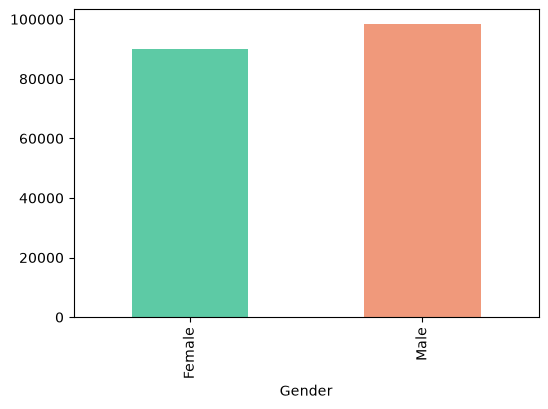

In [5]:
avg_pay = df.groupby('Gender')['BasePay'].mean()
avg_pay.plot(kind='bar', color=['#5DCAA5', '#F0997B'], figsize=(6,4))
plt.title('Average base pay by gender')
plt.ylabel('Salary ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

gap = avg_pay['Male'] - avg_pay['Female']
print(f"\nRaw pay gap: ${gap:,.0f} per year")

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Check exact column names
print(df.columns.tolist())
print("\nShape:", df.shape)
print("\nGender values:", df['Gender'].unique())
print("\nAverage salary by gender:")
print(df.groupby('Gender')['BasePay'].mean())

['JobTitle', 'Gender', 'Age', 'PerfEval', 'Education', 'Dept', 'Seniority', 'BasePay', 'Bonus']

Shape: (1000, 9)

Gender values: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Average salary by gender:
Gender
Female    89942.818376
Male      98457.545113
Name: BasePay, dtype: float64


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Encode categorical columns
df_model = df.copy()

le = LabelEncoder()
df_model['JobTitle_enc'] = le.fit_transform(df_model['JobTitle'])
df_model['Dept_enc'] = le.fit_transform(df_model['Dept'])
df_model['Education_enc'] = le.fit_transform(df_model['Education'])

# Keep gender separate — sensitive feature, NOT a model input
sensitive = df_model['Gender']

# Features the model trains on (no gender!)
X = df_model[['JobTitle_enc', 'Age', 'PerfEval', 'Education_enc', 'Dept_enc', 'Seniority']]
y = df_model['BasePay']

# Split
X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X, y, sensitive, test_size=0.2, random_state=42
)

# Train
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"Model MAE: ${mae:,.0f}")
print(f"\nModel trained on {len(X_train)} rows, tested on {len(X_test)} rows")

Model MAE: $9,942

Model trained on 800 rows, tested on 200 rows


In [9]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import mean_absolute_error
import numpy as np

mf = MetricFrame(
    metrics=mean_absolute_error,
    y_true=y_test,
    y_pred=preds,
    sensitive_features=gender_test
)

print("=== Fairness Report ===")
print(f"\nMAE by gender:")
print(mf.by_group)
print(f"\nOverall MAE: ${mf.overall:,.0f}")
print(f"Disparity (gap in prediction error): ${mf.difference():,.0f}")

=== Fairness Report ===

MAE by gender:
Gender
Female    11062.446289
Male       9024.615234
Name: mean_absolute_error, dtype: float64

Overall MAE: $9,942
Disparity (gap in prediction error): $2,038


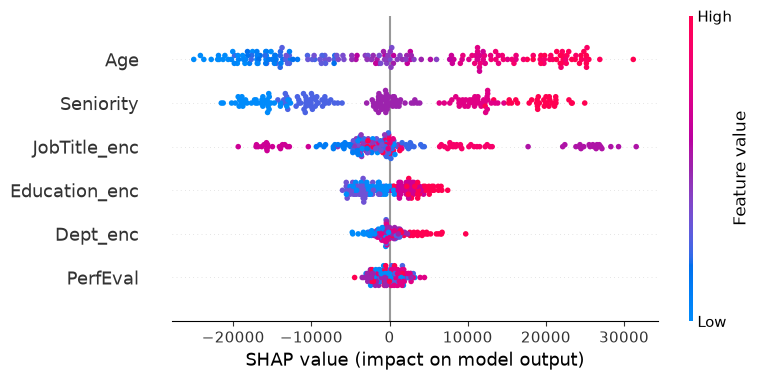

In [11]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Global feature importance — what drives salary the most?
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

Predicted salary: $87,349
Actual salary:    $88,725
Their gender:     Male



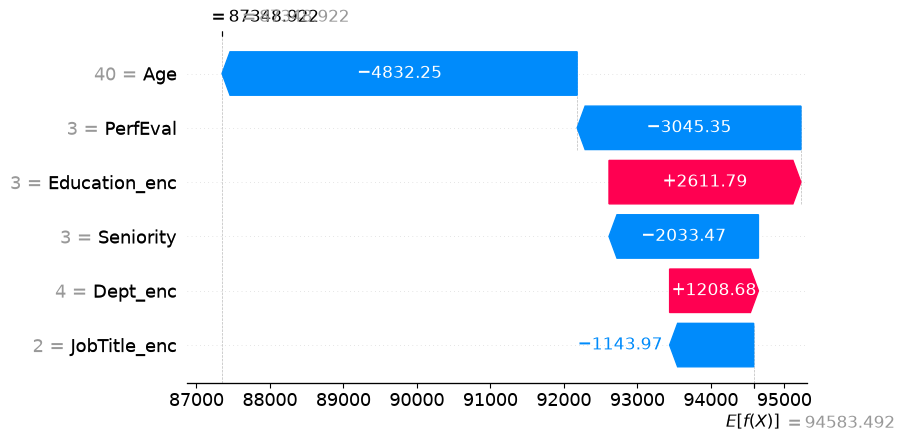

In [12]:
# Pick person 0 from test set and explain their salary prediction
print(f"Predicted salary: ${preds[0]:,.0f}")
print(f"Actual salary:    ${y_test.iloc[0]:,.0f}")
print(f"Their gender:     {gender_test.iloc[0]}")
print()
shap.waterfall_plot(shap_values[0])

In [13]:
import joblib

joblib.dump(model, 'model.pkl')
joblib.dump(le, 'encoder.pkl')

# Save test data for dashboard
X_test.to_csv('data/X_test.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)
gender_test.to_csv('data/gender_test.csv', index=False)

print("Model saved! Ready to build the dashboard.")

Model saved! Ready to build the dashboard.
